In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
from pathlib import Path
import os
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader

from train_utils import get_info
from model import DiagnosticModel
from data import DicomDataset

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
data_dir = Path('/data/vision/polina/users/marcusbl/data')
dataset = DicomDataset(data_dir)

Loading People Data: 100%|██████████| 30/30 [00:00<00:00, 42.45it/s]


0.0 1697.344970703125


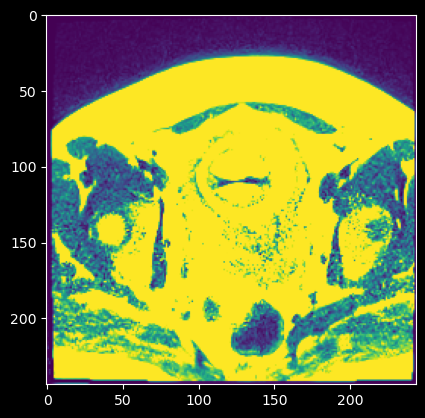

In [10]:
img = dataset[0][0][0]
print(img.min().item(), img.max().item())
plt.imshow(img, vmin = 0, vmax = 255)

In [11]:
norm_params = [
    {'mask_method': None, 'norm_method':'min-max', 'masked_norm': False, 'perc_norm': 0.02, 'title': 'min-max (prec=0.02)'},
    {'mask_method': None, 'norm_method':'peak-squash', 'masked_norm': False, 'perc_norm': 0.02, 'title': 'peak squash'},
    {'mask_method': None, 'norm_method':'min-max', 'masked_norm': False, 'perc_norm': 0, 'title': 'min-max'},
    {'mask_method': None, 'norm_method':'peak-squash', 'masked_norm': True, 'perc_norm': 0.02, 'title': 'peak squash (masked)'},
    {'mask_method': None, 'norm_method':'min-max', 'masked_norm': True, 'perc_norm': 0, 'title': 'min-max (masked)'},
    {'mask_method': None, 'norm_method':'min-max', 'masked_norm': True, 'perc_norm': 0.02, 'title': 'min-max (prec=0.02; masked)'},
    {'mask_method': None, 'norm_method':'min-max', 'masked_norm': True, 'perc_norm': 0.01, 'title': 'min-max (prec=0.01; masked)'},
]

0.0 1.0
0.0 40.0
0.0 1.0
0.0 6.699711799621582
0.0 1.0
0.0 1.0
0.0 1.0


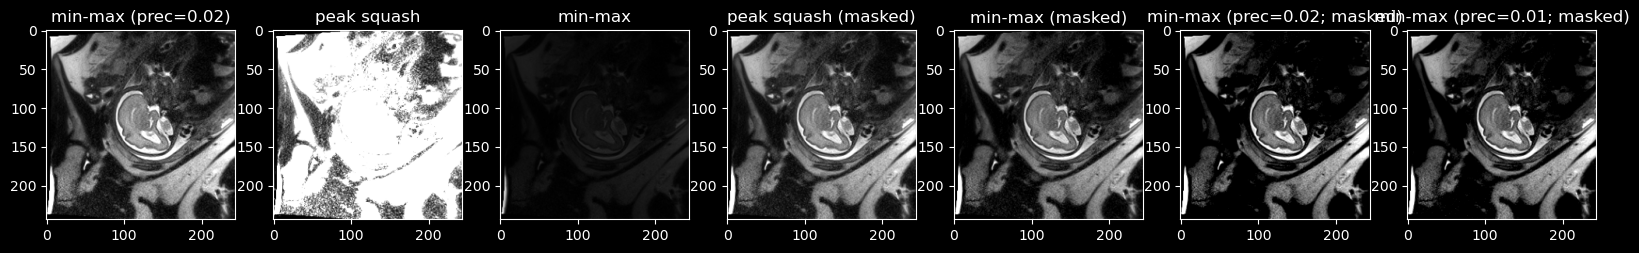

In [141]:
fix, ax = plt.subplots(nrows = 1, ncols = len(norm_params), figsize = (20, 5))  # create a new figure for each image

for i, p in enumerate(norm_params):
    dataset.set_norm(mask_method=p['mask_method'], 
                     norm_method=p['norm_method'], 
                     masked_norm=p['masked_norm'], 
                     perc_norm=p['perc_norm'])
    
    img = dataset[955][0][0]  # assuming shape [C, H, W]
    print(img.min().item(), img.max().item())
    
    # pick first channel if multi-channel
    ax[i].set_title(p['title'])
    ax[i].imshow(img, cmap='gray', vmin=0, vmax=1)  # adjust vmax if needed


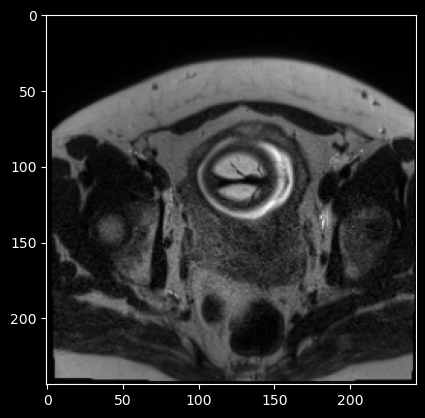

In [116]:
dataset.set_norm()
img = dataset[0][0][0]
plt.imshow(img, cmap='grey') # un-normalized



In [117]:
values = img.flatten()
counts, bin_edges = torch.histogram(values, bins=200)
peak_bin_index = torch.argmax(counts)
x_peak = (bin_edges[peak_bin_index] + bin_edges[peak_bin_index + 1]) / 2

(array([171.,  26.,   1.,   0.,   0.,   0.,   1.,   0.,   0.,   1.]),
 array([   0.        ,  551.29998779, 1102.59997559, 1653.89990234,
        2205.19995117, 2756.5       , 3307.79980469, 3859.09985352,
        4410.39990234, 4961.69970703, 5513.        ]),
 <BarContainer object of 10 artists>)

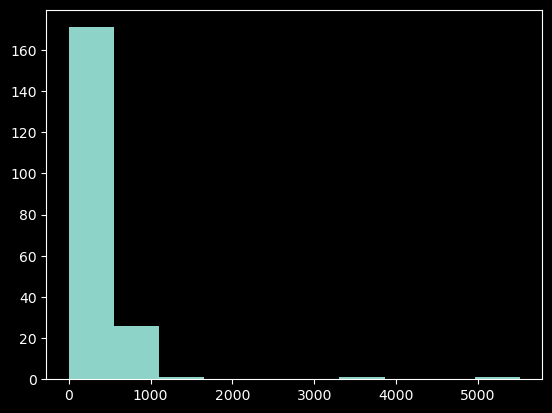

In [118]:
plt.hist(counts)

(array([171.,  26.,   1.,   0.,   0.,   0.,   1.,   0.,   0.,   1.]),
 array([  0.        ,  64.96028137, 129.92056274, 194.88084412,
        259.84112549, 324.8013916 , 389.76168823, 454.72198486,
        519.68225098, 584.64251709, 649.6027832 ]),
 <BarContainer object of 10 artists>)

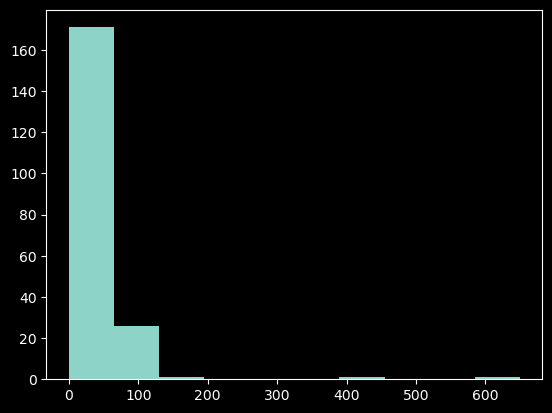

In [119]:
plt.hist(counts / (2 * x_peak))

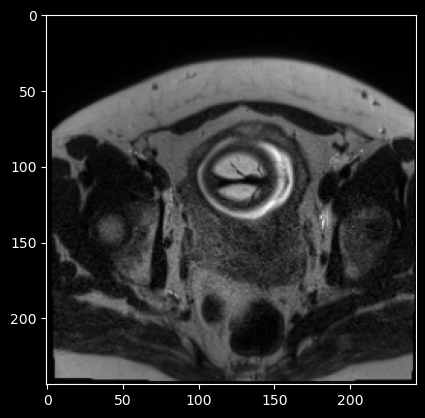

In [120]:
plt.imshow(img / (2 * x_peak), cmap = 'grey')

x_peak: 4.2433624267578125 lower: 3.819025993347168 upper: 4.667698860168457


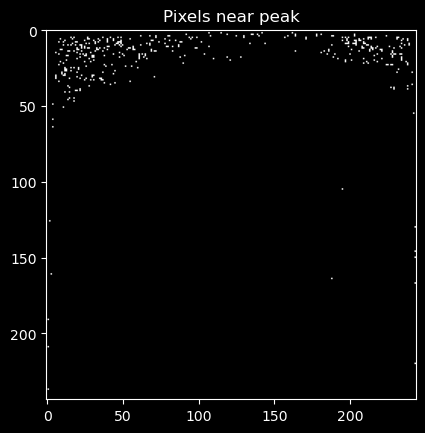

In [140]:
ratio = 0.1
lower = x_peak * (1 - ratio)
upper = x_peak * (1 + ratio)

print("x_peak:", x_peak.item(), "lower:", lower.item(), "upper:", upper.item())

inside = (img >= lower) & (img <= upper)  # boolean mask of values near peak

mask_vis = inside.float()  # 1 = white (inside), 0 = black
plt.imshow(mask_vis, cmap='gray')
plt.title("Pixels near peak")
plt.show()
